# Transformer Model For Language Generation


---
## Cell 1 — Dependencies


In [1]:
import subprocess, sys

PACKAGES = [
    "torch",
    "datasets",
    "transformers",
    "matplotlib",
    "tqdm",
]

for pkg in PACKAGES:
    try:
        __import__(pkg)
        print(f"OK  {pkg} already installed")
    except ImportError:
        print(f"Package  Installing {pkg} …")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        print(f"OK  {pkg} installed")

print("\nAll dependencies ready.")


OK  torch already installed
OK  datasets already installed
OK  transformers already installed
OK  matplotlib already installed
OK  tqdm already installed

All dependencies ready.


---
## Cell 2 - Import libraries


In [2]:
import time
import math
import torch
import warnings
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from typing import Optional

warnings.filterwarnings("ignore")

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Apple MPS (Metal) GPU detected — using MPS acceleration!")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"CUDA GPU detected: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu")
    print("No GPU found — running on CPU")

print(f"Active device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

SEED = 42
torch.manual_seed(SEED)


Apple MPS (Metal) GPU detected — using MPS acceleration!
Active device: mps
PyTorch version: 2.11.0


---
## Cell 3 — Hyperparameters


In [3]:
D_MODEL      = 256
N_HEADS      = 8
N_ENCODER    = 4
N_DECODER    = 4
D_FF         = 1024
DROPOUT      = 0.25
MAX_SEQ_LEN  = 80

BATCH_SIZE      = 32
EPOCHS          = 36
LEARNING_RATE   = 2e-4
WEIGHT_DECAY    = 0.05
CLIP_GRAD       = 1.0
WARMUP_STEPS    = 2000
MAX_SAMPLES     = 48000
LABEL_SMOOTHING = 0.15
PATIENCE        = 8

BEAM_WIDTH   = 4
MAX_GEN_LEN  = 30
TEMPERATURE  = 0.7
K_TOKENS     = 40
PENALTY      = 1.2


---
## Cell 4 — Load dataset


In [4]:
from datasets import load_dataset

print("Loading daily_dialog dataset…")
raw = load_dataset("DeepPavlov/daily_dialog", split="train") 
print(f"Total dialogs loaded: {len(raw)}")

pairs = []
for row in raw:
    dialog = row["dialog"] 
    for i in range(len(dialog) - 1):
        src = dialog[i].strip()
        tgt = dialog[i + 1].strip()
        if src and tgt:
            pairs.append((src, tgt))

pairs = pairs[:MAX_SAMPLES]
print(f"{len(pairs)} dialog pairs used for training")


Loading daily_dialog dataset…
Total dialogs loaded: 87170
48000 dialog pairs used for training


---
## Cell 5 — Tokenizer


In [5]:
from transformers import AutoTokenizer

print("Loading GPT-2 Subword Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("gpt2")

tokenizer.add_special_tokens({'pad_token': '<pad>', 'bos_token': '<bos>'})
VOCAB_SIZE = len(tokenizer)

PAD_IDX = tokenizer.pad_token_id
BOS_IDX = tokenizer.bos_token_id
EOS_IDX = tokenizer.eos_token_id

print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"PAD={PAD_IDX}, BOS={BOS_IDX}, EOS={EOS_IDX}")

test_enc = tokenizer.encode("Hello, how are you?", add_special_tokens=True)
print(f"\nEncoded: {test_enc}")
print(f"Decoded: {tokenizer.decode(test_enc)}")


Loading GPT-2 Subword Tokenizer...


Vocabulary size: 50259
PAD=50257, BOS=50258, EOS=50256

Encoded: [15496, 11, 703, 389, 345, 30]
Decoded: Hello, how are you?


---
## Cell 6 — PyTorch Dataset & DataLoader


In [6]:
class DialogDataset(Dataset):
    def __init__(self, pairs, tokenizer, max_len: int):
        self.samples = []
        for src_txt, tgt_txt in pairs:
            src_ids = tokenizer.encode(src_txt, truncation=True, max_length=max_len)
            tgt_ids_full = tokenizer.encode(tgt_txt + tokenizer.eos_token, truncation=True, max_length=max_len + 1)
            
            src_padded = self._pad(src_ids, max_len)
            tgt_in = self._pad([tokenizer.bos_token_id] + tgt_ids_full[:-1], max_len)
            tgt_out = self._pad(tgt_ids_full, max_len)
            
            self.samples.append((src_padded, tgt_in, tgt_out))

    def _pad(self, seq, max_len):
        seq = seq[:max_len]
        return seq + [tokenizer.pad_token_id] * (max_len - len(seq))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        src, ti, to = self.samples[idx]
        return (
            torch.tensor(src, dtype=torch.long),
            torch.tensor(ti,  dtype=torch.long),
            torch.tensor(to,  dtype=torch.long),
        )

split = int(0.8 * len(pairs))
train_ds = DialogDataset(pairs[:split], tokenizer, MAX_SEQ_LEN)
valid_ds = DialogDataset(pairs[split:], tokenizer, MAX_SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train samples: {len(train_ds)}  |  batches/epoch: {len(train_loader)}")
print(f"Valid samples: {len(valid_ds)}  |  batches/epoch: {len(valid_loader)}")


Train samples: 38400  |  batches/epoch: 1200
Valid samples: 9600  |  batches/epoch: 300


---
## Cell 7 — Positional Encoding


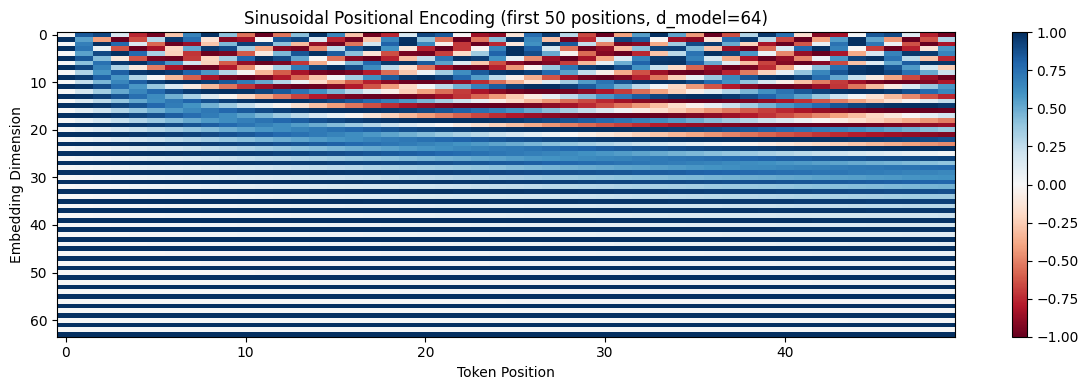

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, : x.size(1), :]
        return self.dropout(x)

pe_module = PositionalEncoding(d_model=64, max_len=100)
pe_matrix = pe_module.pe.squeeze(0).detach().numpy()

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pe_matrix[:50, :].T, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
ax.set_xlabel("Token Position")
ax.set_ylabel("Embedding Dimension")
ax.set_title("Sinusoidal Positional Encoding (first 50 positions, d_model=64)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


---
## Cell 8 — Multi-Head Attention


In [8]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.d_model  = d_model
        self.n_heads  = n_heads
        self.d_k      = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

        self.dropout = nn.Dropout(dropout)
        self.scale   = math.sqrt(self.d_k)

    def split_heads(self, x: torch.Tensor) -> torch.Tensor:
        B, T, _ = x.shape
        x = x.view(B, T, self.n_heads, self.d_k)
        return x.transpose(1, 2)

    def forward(
        self,
        query: torch.Tensor,
        key:   torch.Tensor,
        value: torch.Tensor,
        mask:  Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        B = query.size(0)

        Q = self.split_heads(self.W_q(query))
        K = self.split_heads(self.W_k(key))
        V = self.split_heads(self.W_v(value))

        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        if mask is not None:
            scores = scores.masked_fill(mask, float("-inf"))

        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context = torch.matmul(attn_weights, V)

        context = context.transpose(1, 2).contiguous().view(B, -1, self.d_model)
        output  = self.W_o(context)
        return output

print("MultiHeadAttention defined.")

_mha = MultiHeadAttention(D_MODEL, N_HEADS)
_x   = torch.randn(2, 10, D_MODEL)
_out = _mha(_x, _x, _x)
print(f"MHA self-attention test — input: {_x.shape}  output: {_out.shape}")


MultiHeadAttention defined.
MHA self-attention test — input: torch.Size([2, 10, 256])  output: torch.Size([2, 10, 256])


---
## Cell 9 — Position-wise Feed-Forward Network & Layer utilities


In [9]:
class PositionwiseFFN(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear2(self.dropout(F.gelu(self.linear1(x))))

class AddNorm(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, sublayer_output: torch.Tensor) -> torch.Tensor:
        return self.norm(x + self.dropout(sublayer_output))


---
## Cell 10 — Encoder Layer & Encoder Stack


In [10]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn       = PositionwiseFFN(d_model, d_ff, dropout)
        self.add_norm1 = AddNorm(d_model, dropout)
        self.add_norm2 = AddNorm(d_model, dropout)

    def forward(
        self,
        x: torch.Tensor,
        src_mask: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        x = self.add_norm1(x, self.self_attn(x, x, x, mask=src_mask))
        x = self.add_norm2(x, self.ffn(x))
        return x

class Encoder(nn.Module):
    def __init__(
        self, vocab_size: int, d_model: int, n_layers: int,
        n_heads: int, d_ff: int, max_len: int, dropout: float, pad_idx: int
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.scale     = math.sqrt(d_model)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        self.layers    = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.norm      = nn.LayerNorm(d_model)

    def forward(
        self,
        src: torch.Tensor,
        src_mask: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        x = self.pos_enc(self.embedding(src) * self.scale)
        for layer in self.layers:
            x = layer(x, src_mask)
        return self.norm(x)


---
## Cell 11 — Decoder Layer & Decoder Stack


In [11]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float):
        super().__init__()
        self.masked_self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn       = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn              = PositionwiseFFN(d_model, d_ff, dropout)
        self.add_norm1        = AddNorm(d_model, dropout)
        self.add_norm2        = AddNorm(d_model, dropout)
        self.add_norm3        = AddNorm(d_model, dropout)

    def forward(
        self,
        x:          torch.Tensor,
        enc_output: torch.Tensor,
        src_mask:   Optional[torch.Tensor] = None,
        tgt_mask:   Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        x = self.add_norm1(x, self.masked_self_attn(x, x, x, mask=tgt_mask))
        x = self.add_norm2(x, self.cross_attn(x, enc_output, enc_output, mask=src_mask))
        x = self.add_norm3(x, self.ffn(x))
        return x

class Decoder(nn.Module):
    def __init__(
        self, vocab_size: int, d_model: int, n_layers: int,
        n_heads: int, d_ff: int, max_len: int, dropout: float, pad_idx: int
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.scale     = math.sqrt(d_model)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        self.layers    = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.norm      = nn.LayerNorm(d_model)

    def forward(
        self,
        tgt:        torch.Tensor,
        enc_output: torch.Tensor,
        src_mask:   Optional[torch.Tensor] = None,
        tgt_mask:   Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        x = self.pos_enc(self.embedding(tgt) * self.scale)
        for layer in self.layers:
            x = layer(x, enc_output, src_mask, tgt_mask)
        return self.norm(x)


---
## Cell 12 — Full Transformer Model


In [12]:
class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model=512, n_encoder=4, n_decoder=4, n_heads=8, d_ff=2048, max_len=512, dropout=0.1, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.d_model = d_model

        self.encoder = Encoder(vocab_size, d_model, n_encoder, n_heads, d_ff, max_len, dropout, pad_idx)
        self.decoder = Decoder(vocab_size, d_model, n_decoder, n_heads, d_ff, max_len, dropout, pad_idx)

        self.linear_out = nn.Linear(d_model, vocab_size)
        self.linear_out.weight = self.encoder.embedding.weight

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def make_src_mask(self, src: torch.Tensor) -> torch.Tensor:
        return (src == self.pad_idx).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt: torch.Tensor) -> torch.Tensor:
        B, T = tgt.shape
        causal = torch.triu(torch.ones(T, T, device=tgt.device), diagonal=1).bool()
        pad_mask = (tgt == self.pad_idx).unsqueeze(1).unsqueeze(2)
        return causal.unsqueeze(0).unsqueeze(0) | pad_mask

    def forward(self, src: torch.Tensor, tgt: torch.Tensor) -> torch.Tensor:
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)

        enc_output = self.encoder(src, src_mask)
        dec_output = self.decoder(tgt, enc_output, src_mask, tgt_mask)
        logits = self.linear_out(dec_output)
        return logits

model = Transformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_encoder=N_ENCODER,
    n_decoder=N_DECODER,
    n_heads=N_HEADS,
    d_ff=D_FF,
    max_len=MAX_SEQ_LEN + 10,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model created on {DEVICE}")
print(f"Trainable parameters: {n_params:,}")


Model created on mps
Trainable parameters: 33,144,403


---
## Cell 13 — Training loop


In [13]:
def make_warmup_cosine_scheduler(optimizer, warmup_steps, total_steps):
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / float(max(1, warmup_steps))
        progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

optimizer  = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion  = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=LABEL_SMOOTHING)

total_steps = len(train_loader) * EPOCHS
scheduler   = make_warmup_cosine_scheduler(optimizer, WARMUP_STEPS, total_steps)

def run_epoch(loader, train: bool) -> float:
    model.train(train)
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for src, tgt_in, tgt_out in loader:
            src, tgt_in, tgt_out = src.to(DEVICE), tgt_in.to(DEVICE), tgt_out.to(DEVICE)
            logits = model(src, tgt_in)
            loss   = criterion(logits.view(-1, VOCAB_SIZE), tgt_out.view(-1))
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
                optimizer.step()
                scheduler.step()
            total_loss += loss.item()
    return total_loss / len(loader)

train_losses, valid_losses = [], []
best_valid_loss  = float("inf")
epochs_no_improve = 0

print(f"Starting training for up to {EPOCHS} epochs on {DEVICE} …\n")
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    t_ep   = time.time()
    tr_loss = run_epoch(train_loader, train=True)
    va_loss = run_epoch(valid_loader, train=False)

    train_losses.append(tr_loss)
    valid_losses.append(va_loss)

    elapsed = time.time() - t_ep
    ratio   = tr_loss / va_loss if va_loss > 0 else 0.0
    current_lr = scheduler.get_last_lr()[0]

    if va_loss < best_valid_loss:
        best_valid_loss   = va_loss
        epochs_no_improve = 0
        tag = "BEST"
        torch.save(model.state_dict(), "transformer_best.pt")
    else:
        epochs_no_improve += 1
        tag = f"no_improve={epochs_no_improve}/{PATIENCE}"

    print(f"Epoch {epoch:02d}/{EPOCHS}  train={tr_loss:.4f}  val={va_loss:.4f}  ratio={ratio:.2f}  lr={current_lr:.2e}  time={elapsed:.1f}s  {tag}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered after {epoch} epochs.")
        break

print(f"\nTotal training time: {(time.time()-t0)/60:.1f} min")
print(f"Best validation loss: {best_valid_loss:.4f}")


Starting training for up to 36 epochs on mps …

Epoch 01/36  train=8.1366  val=6.6582  ratio=1.22  lr=1.20e-04  time=1224.8s  BEST
Epoch 02/36  train=6.0107  val=5.9713  ratio=1.01  lr=2.00e-04  time=1229.0s  BEST
Epoch 03/36  train=5.4767  val=5.8762  ratio=0.93  lr=1.99e-04  time=1220.3s  BEST
Epoch 04/36  train=5.1506  val=5.8572  ratio=0.88  lr=1.98e-04  time=1216.7s  BEST
Epoch 05/36  train=4.8746  val=5.9054  ratio=0.83  lr=1.95e-04  time=854.0s  no_improve=1/8
Epoch 06/36  train=4.6128  val=5.9388  ratio=0.78  lr=1.92e-04  time=715.0s  no_improve=2/8
Epoch 07/36  train=4.3672  val=6.0165  ratio=0.73  lr=1.88e-04  time=750.0s  no_improve=3/8
Epoch 08/36  train=4.1434  val=6.0873  ratio=0.68  lr=1.84e-04  time=733.3s  no_improve=4/8
Epoch 09/36  train=3.9465  val=6.1732  ratio=0.64  lr=1.78e-04  time=734.4s  no_improve=5/8
Epoch 10/36  train=3.7718  val=6.2738  ratio=0.60  lr=1.72e-04  time=731.0s  no_improve=6/8
Epoch 11/36  train=3.6244  val=6.3071  ratio=0.57  lr=1.66e-04  time

---
## Cell 14 — Training curve


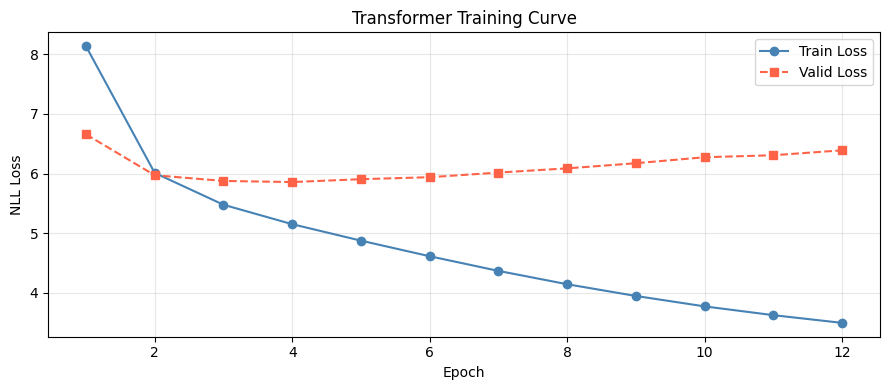

In [14]:
epochs_ran = len(train_losses)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, epochs_ran + 1), train_losses, "o-", label="Train Loss", color="steelblue")
ax.plot(range(1, epochs_ran + 1), valid_losses, "s--", label="Valid Loss", color="tomato")
ax.set_xlabel("Epoch")
ax.set_ylabel("NLL Loss")
ax.set_title("Transformer Training Curve")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## Cell 15 — Beam Search Inference


In [15]:
model.load_state_dict(torch.load("transformer_best.pt", map_location=DEVICE))
model.eval()

def apply_repetition_penalty(logits, generated_ids, penalty=1.2):
    for token_id in set(generated_ids):
        score = logits[token_id]
        if score < 0:
            logits[token_id] = score * penalty
        else:
            logits[token_id] = score / penalty
    return logits

def greedy_decode(prompt: str, max_len: int = MAX_GEN_LEN, rep_penalty: float = 1.2) -> str:
    src_ids = tokenizer.encode(prompt, truncation=True, max_length=MAX_SEQ_LEN)
    src = torch.tensor([src_ids], dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        src_mask = model.make_src_mask(src)
        enc_output = model.encoder(src, src_mask)
        generated = [tokenizer.bos_token_id]
        
        for _ in range(max_len):
            tgt = torch.tensor([generated], dtype=torch.long, device=DEVICE)
            tgt_mask = model.make_tgt_mask(tgt)
            dec_out = model.decoder(tgt, enc_output, src_mask, tgt_mask)
            
            logits = model.linear_out(dec_out[:, -1, :]).squeeze(0)
            
            if rep_penalty != 1.0:
                logits = apply_repetition_penalty(logits, generated, rep_penalty)
                
            next_id = logits.argmax(-1).item()
            if next_id == tokenizer.eos_token_id:
                break
            generated.append(next_id)

    return tokenizer.decode(generated[1:], skip_special_tokens=True)

def beam_search_decode(prompt: str, beam_width: int = BEAM_WIDTH, max_len: int = MAX_GEN_LEN, rep_penalty: float = 1.2) -> str:
    src_ids = tokenizer.encode(prompt, truncation=True, max_length=MAX_SEQ_LEN)
    src = torch.tensor([src_ids], dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        src_mask = model.make_src_mask(src)
        enc_output = model.encoder(src, src_mask)
        beams = [([tokenizer.bos_token_id], 0.0)]
        completed = []

        for step in range(max_len):
            candidates = []
            for seq, score in beams:
                if seq[-1] == tokenizer.eos_token_id:
                    completed.append((seq, score))
                    continue

                tgt = torch.tensor([seq], dtype=torch.long, device=DEVICE)
                tgt_mask = model.make_tgt_mask(tgt)
                dec_out  = model.decoder(tgt, enc_output, src_mask, tgt_mask)
                
                logits = model.linear_out(dec_out[:, -1, :]).squeeze(0)
                
                if rep_penalty != 1.0:
                    logits = apply_repetition_penalty(logits, seq, rep_penalty)
                
                log_probs = F.log_softmax(logits, dim=-1)
                topk_lp, topk_ids = log_probs.topk(beam_width)
                
                for lp, tid in zip(topk_lp.tolist(), topk_ids.tolist()):
                    candidates.append((seq + [tid], score + lp))

            if not candidates:
                break

            candidates.sort(key=lambda x: x[1], reverse=True)
            beams = candidates[:beam_width]

            if all(seq[-1] == tokenizer.eos_token_id for seq, _ in beams):
                completed.extend(beams)
                break

        if not completed:
            completed = beams
        best_seq, _ = max(completed, key=lambda x: x[1])

    return tokenizer.decode(best_seq[1:], skip_special_tokens=True)

def sample_decode(prompt: str, max_len: int = MAX_GEN_LEN, temperature: float = TEMPERATURE, top_k: int = 40, rep_penalty: float = 1.2) -> str:
    src_ids = tokenizer.encode(prompt, truncation=True, max_length=MAX_SEQ_LEN)
    src = torch.tensor([src_ids], dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        src_mask = model.make_src_mask(src)
        enc_output = model.encoder(src, src_mask)
        generated = [tokenizer.bos_token_id]

        for _ in range(max_len):
            tgt = torch.tensor([generated], dtype=torch.long, device=DEVICE)
            tgt_mask = model.make_tgt_mask(tgt)
            dec_out = model.decoder(tgt, enc_output, src_mask, tgt_mask)
            
            logits = model.linear_out(dec_out[:, -1, :]).squeeze(0)

            if rep_penalty != 1.0:
                logits = apply_repetition_penalty(logits, generated, rep_penalty)

            logits = logits / temperature

            if top_k > 0:
                top_k_val = torch.topk(logits, top_k)[0][-1]
                logits[logits < top_k_val] = float('-inf')

            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()

            if next_id == tokenizer.eos_token_id:
                break
            generated.append(next_id)

    return tokenizer.decode(generated[1:], skip_special_tokens=True)


---
## Cell 16 — Text generation examples


In [16]:
PROMPTS = [
    "Hello, how's it going?",
    "Where are you from?",
    "How are you today?",
    "Nice to meet you.",
]

print("=" * 60)
print("Transformer Text Generation Results")
print("=" * 60)

for prompt in PROMPTS:
    greedy_out = greedy_decode(prompt, rep_penalty=PENALTY)
    beam_out   = beam_search_decode(prompt, beam_width=BEAM_WIDTH, rep_penalty=PENALTY)
    sample_out = sample_decode(prompt, temperature=TEMPERATURE, top_k=K_TOKENS, rep_penalty=PENALTY)
    
    print(f"Prompt     : {prompt}")
    print(f"Greedy     : {greedy_out}")
    print(f"Beam({BEAM_WIDTH})    : {beam_out}")
    print(f"Sample     : {sample_out}")
    print("-" * 60)
    

Transformer Text Generation Results
Prompt     : Hello, how's it going?
Greedy     : I don't know . I'm not like it .
Beam(4)    : I don't know .
Sample     : It's great .
------------------------------------------------------------
Prompt     : Where are you from?
Greedy     : I'm not sure .
Beam(4)    : I don't know .
Sample     : It's a good structure .
------------------------------------------------------------
Prompt     : How are you today?
Greedy     : I'm not sure .
Beam(4)    : I don't know .
Sample     : Yes , I think we will .
------------------------------------------------------------
Prompt     : Nice to meet you.
Greedy     : I'm sorry . I've got to get a few books .
Beam(4)    : I don't know .
Sample     : I'm going to go back for a year .
------------------------------------------------------------


---
## Cell 17 — Attention weight visualisation


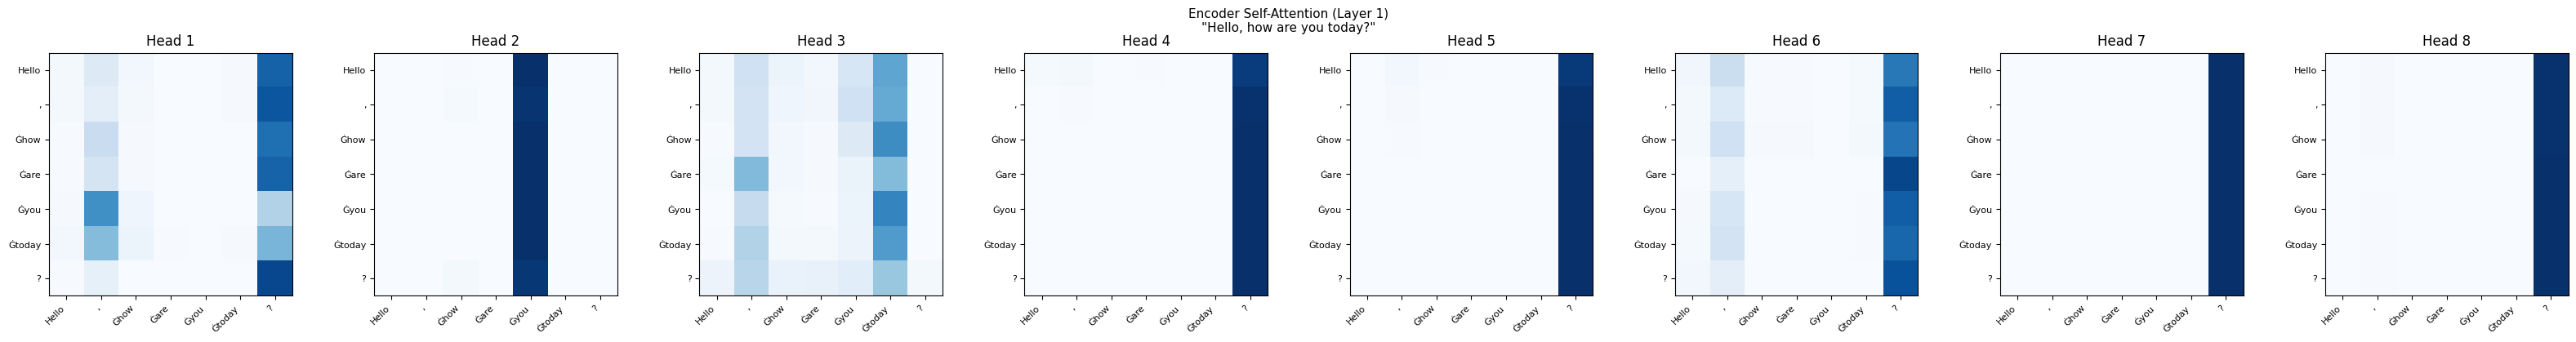

In [17]:
def get_attention_weights(prompt: str):
    model.eval()
    src_ids = tokenizer.encode(prompt, truncation=True, max_length=MAX_SEQ_LEN)
    tokens = tokenizer.convert_ids_to_tokens(src_ids)
    src = torch.tensor([src_ids], dtype=torch.long, device=DEVICE)

    attn_weights_store = []

    def hook_fn(module, input, output):
        Q = module.split_heads(module.W_q(input[0]))
        K = module.split_heads(module.W_k(input[1]))
        scale = math.sqrt(module.d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / scale
        w = torch.softmax(scores, dim=-1).detach().cpu()
        attn_weights_store.append(w)

    handle = model.encoder.layers[0].self_attn.register_forward_hook(hook_fn)
    with torch.no_grad():
        src_mask = model.make_src_mask(src)
        model.encoder(src, src_mask)
    handle.remove()

    return attn_weights_store[0].squeeze(0), tokens

VIS_PROMPT = "Hello, how are you today?"
attn, tok_labels = get_attention_weights(VIS_PROMPT)
n_heads = attn.shape[0]
T = min(attn.shape[-1], len(tok_labels))
tok_labels = tok_labels[:T]

fig, axes = plt.subplots(1, n_heads, figsize=(4 * n_heads, 4))
if n_heads == 1:
    axes = [axes]
for h, ax in enumerate(axes):
    im = ax.imshow(attn[h, :T, :T].numpy(), vmin=0, vmax=1, cmap="Blues")
    ax.set_xticks(range(T))
    ax.set_xticklabels(tok_labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(T))
    ax.set_yticklabels(tok_labels, fontsize=8)
    ax.set_title(f"Head {h+1}")
plt.suptitle(f'Encoder Self-Attention (Layer 1)\n"{VIS_PROMPT}"', fontsize=11)
plt.tight_layout()
plt.show()


---
## Cell 18 — Save & reload model


In [18]:
import pickle

torch.save(model.state_dict(), "transformer_weights.pt")

with open("transformer_vocab.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Model weights saved to: transformer_weights.pt")
print("Vocabulary saved to:    transformer_vocab.pkl")

with open("transformer_vocab.pkl", "rb") as f:
    loaded_vocab = pickle.load(f)

loaded_model = Transformer(
    vocab_size=len(loaded_vocab),
    d_model=D_MODEL, n_encoder=N_ENCODER, n_decoder=N_DECODER,
    n_heads=N_HEADS, d_ff=D_FF, max_len=MAX_SEQ_LEN + 10,
    dropout=DROPOUT, pad_idx=loaded_vocab.pad_token_id,
).to(DEVICE)
loaded_model.load_state_dict(torch.load("transformer_weights.pt", map_location=DEVICE))
loaded_model.eval()

print("\nModel reloaded successfully.")
print("Verification:")
print(f"  Prompt  : Hello, hows it going?")
print(f"  Response: {sample_decode('Hello, hows it going?', temperature=TEMPERATURE, top_k=K_TOKENS, rep_penalty=PENALTY)}")


Model weights saved to: transformer_weights.pt
Vocabulary saved to:    transformer_vocab.pkl

Model reloaded successfully.
Verification:
  Prompt  : Hello, hows it going?
  Response: That's a problem . We can have to be more at the morning , but I'm sure we'll do good for you .


**FIRST TEST:**

This baseline Transformer model employs a hidden dimension of 256 and 8 attention heads distributed across 4 encoder and 4 decoder layers. Training was executed with a batch size of 16 and a learning rate of 3e-4, ultimately triggering an early stopping mechanism at epoch 14 with a best validation loss of 5.4399. While the network successfully learned basic syntactic structures, the generated dialog responses suffer from repetitive and contextually misaligned outputs during inference, indicating limited conversational comprehension.

**HYPERPARAMETERS:**

D_MODEL      = 256  
N_HEADS      = 8  
N_ENCODER    = 4  
N_DECODER    = 4  
D_FF         = 1024  
DROPOUT      = 0.15  
MAX_SEQ_LEN  = 80  

BATCH_SIZE      = 16  
EPOCHS          = 60  
LEARNING_RATE   = 3e-4  
WEIGHT_DECAY    = 1e-2  
CLIP_GRAD       = 1.0  
WARMUP_STEPS    = 1200  
MAX_SAMPLES     = 48000  
LABEL_SMOOTHING = 0.1  
PATIENCE        = 10  

BEAM_WIDTH   = 4  
MAX_GEN_LEN  = 30  
TEMPERATURE  = 0.7  
K_TOKENS     = 40  
PENALTY      = 1.2  

**TRAINING:**  

Starting training for up to 48 epochs on mps …  

Epoch 01/48  train=8.2526  val=6.5867  ratio=1.25  lr=1.00e-04  time=535.0s  BEST  
Epoch 02/48  train=5.9611  val=5.7257  ratio=1.04  lr=9.98e-05  time=527.9s  BEST  
Epoch 03/48  train=5.3944  val=5.5548  ratio=0.97  lr=9.94e-05  time=523.9s  BEST  
Epoch 04/48  train=5.1523  val=5.4942  ratio=0.94  lr=9.88e-05  time=518.3s  BEST  
Epoch 05/48  train=4.9777  val=5.4596  ratio=0.91  lr=9.79e-05  time=525.4s  BEST  
Epoch 06/48  train=4.8200  val=5.4399  ratio=0.89  lr=9.69e-05  time=521.9s  BEST  
Epoch 07/48  train=4.6695  val=5.4435  ratio=0.86  lr=9.56e-05  time=523.6s  no_improve=1/8  
Epoch 08/48  train=4.5267  val=5.4510  ratio=0.83  lr=9.42e-05  time=520.8s  no_improve=2/8  
Epoch 09/48  train=4.3899  val=5.4732  ratio=0.80  lr=9.25e-05  time=519.3s  no_improve=3/8  
Epoch 10/48  train=4.2635  val=5.4973  ratio=0.78  lr=9.07e-05  time=522.7s  no_improve=4/8  
Epoch 11/48  train=4.1423  val=5.5336  ratio=0.75  lr=8.87e-05  time=521.9s  no_improve=5/8  
Epoch 12/48  train=4.0296  val=5.5615  ratio=0.72  lr=8.65e-05  time=523.1s  no_improve=6/8  
Epoch 13/48  train=3.9232  val=5.5923  ratio=0.70  lr=8.42e-05  time=521.6s  no_improve=7/8  
Epoch 14/48  train=3.8249  val=5.6268  ratio=0.68  lr=8.17e-05  time=522.2s  no_improve=8/8  

Early stopping triggered after 14 epochs.  

Total training time: 122.1 min  
Best validation loss: 5.4399  

**RESULTS:**  

Prompt     : Hello, how's it going?  
Greedy     : I'm not sure .  
Beam(4)    : Yes .  
Sample     : Oh , I'm not a long bad idea .  

Prompt     : Where are you from?  
Greedy     : I'm not sure . I was a lot of music .  
Beam(4)    : Yes , I don't .  
Sample     : No , I'm so bad .  

Prompt     : How are you today?  
Greedy     : I'm not sure . I don't know that .  
Beam(4)    : Yes , I don't .  
Sample     : no , I'm not going to meet you .  

Prompt     : Nice to meet you.  
Greedy     : I'm not sure .  
Beam(4)    : Yes .  
Sample     : I think I will tell me the weather . Don't you have a very chance of his new night .  

---

**SECOND TEST:**

This configuration tests a lighter Transformer architecture with a reduced hidden dimension of 192, 6 attention heads, and 3 layers for both the encoder and decoder. To compensate for the reduced capacity, the batch size was doubled to 32 and the learning rate was adjusted to 2e-4. The training process triggered early stopping after 11 epochs with a best validation loss of 5.4241, demonstrating a slightly faster convergence than the baseline. Despite these architectural changes, the generated inference outputs continue to struggle with semantic context, frequently defaulting to generic fallback tokens.

**HYPERPARAMETERS:**

D_MODEL      = 192  
N_HEADS      = 6  
N_ENCODER    = 3  
N_DECODER    = 3  
D_FF         = 768  
DROPOUT      = 0.15  
MAX_SEQ_LEN  = 64  

BATCH_SIZE      = 32  
EPOCHS          = 36  
LEARNING_RATE   = 2e-4  
WEIGHT_DECAY    = 1e-2  
CLIP_GRAD       = 1.0  
WARMUP_STEPS    = 800  
MAX_SAMPLES     = 48000  
LABEL_SMOOTHING = 0.1  

PATIENCE     = 8  
BEAM_WIDTH   = 4  
MAX_GEN_LEN  = 30  
TEMPERATURE  = 0.7  
K_TOKENS     = 40  
PENALTY      = 1.2  

**TRAINING:**  

Starting training for up to 36 epochs on mps …  

Epoch 01/36  train=7.1860  val=5.6326  ratio=1.28  lr=2.00e-04  time=734.3s  BEST  
Epoch 02/36  train=5.1039  val=5.4330  ratio=0.94  lr=1.99e-04  time=737.6s  BEST  
Epoch 03/36  train=4.6390  val=5.4241  ratio=0.86  lr=1.98e-04  time=712.0s  BEST  
Epoch 04/36  train=4.2375  val=5.5011  ratio=0.77  lr=1.96e-04  time=723.0s  no_improve=1/8  
Epoch 05/36  train=3.8605  val=5.5932  ratio=0.69  lr=1.93e-04  time=725.8s  no_improve=2/8  
Epoch 06/36  train=3.5143  val=5.7050  ratio=0.62  lr=1.89e-04  time=719.6s  no_improve=3/8  
Epoch 07/36  train=3.2159  val=5.8167  ratio=0.55  lr=1.85e-04  time=733.3s  no_improve=4/8  
Epoch 08/36  train=2.9623  val=5.9592  ratio=0.50  lr=1.79e-04  time=707.5s  no_improve=5/8  
Epoch 09/36  train=2.7568  val=6.0941  ratio=0.45  lr=1.74e-04  time=718.7s  no_improve=6/8  
Epoch 10/36  train=2.5887  val=6.1996  ratio=0.42  lr=1.67e-04  time=724.7s  no_improve=7/8  
Epoch 11/36  train=2.4522  val=6.3139  ratio=0.39  lr=1.61e-04  time=724.5s  no_improve=8/8  

Early stopping triggered after 11 epochs.  

Total training time: 132.7 min  
Best validation loss: 5.4241  

**RESULTS:**  

Prompt     : Hello, how's it going?  
Greedy     : I'm not sure .  
Beam(4)    : I don't know .  
Sample     : How about your car ?  

Prompt     : Where are you from?  
Greedy     : I'm sorry . I was just got a few months .  
Beam(4)    : Yes , it's .  
Sample     : When ?  

Prompt     : How are you today?  
Greedy     : I'm sorry . I was just got a few months .  
Beam(4)    : Yes , it's .  
Sample     : Yeah , but I am sure .  

Prompt     : Nice to meet you.  
Greedy     : I'm sorry . I've got a lot of course .  
Beam(4)    : I'm sorry .  
Sample     : I've got a student .  

---

**LAST TEST:**

This final model variant reverts to the more expressive 256-dimensional representation but introduces stronger regularization via a dropout rate of 0.25 and a higher weight decay coefficient of 0.05. It also leverages an extended warmup period of 2000 steps alongside a batch size of 32 to better stabilize the initial AdamW gradient updates. Early stopping was engaged at epoch 12, yielding the highest validation loss among the three trials at 5.8572. However, the qualitative inference results exhibit a slight improvement in dialogue diversity when temperature sampling is applied, even though deterministic search methods heavily favor repetitive phrases.

**HYPERPARAMETERS:**

D_MODEL      = 256  
N_HEADS      = 8  
N_ENCODER    = 4  
N_DECODER    = 4  
D_FF         = 1024  
DROPOUT      = 0.25  
MAX_SEQ_LEN  = 80  

BATCH_SIZE      = 32  
EPOCHS          = 36  
LEARNING_RATE   = 2e-4  
WEIGHT_DECAY    = 0.05  
CLIP_GRAD       = 1.0  
WARMUP_STEPS    = 2000  
MAX_SAMPLES     = 48000  
LABEL_SMOOTHING = 0.15  
PATIENCE        = 8  

BEAM_WIDTH   = 4  
MAX_GEN_LEN  = 30  
TEMPERATURE  = 0.7  
K_TOKENS     = 40  
PENALTY      = 1.2  

**TRAINING:**  

Starting training for up to 36 epochs on mps …  

Epoch 01/36  train=8.1366  val=6.6582  ratio=1.22  lr=1.20e-04  time=1224.8s  BEST  
Epoch 02/36  train=6.0107  val=5.9713  ratio=1.01  lr=2.00e-04  time=1229.0s  BEST  
Epoch 03/36  train=5.4767  val=5.8762  ratio=0.93  lr=1.99e-04  time=1220.3s  BEST  
Epoch 04/36  train=5.1506  val=5.8572  ratio=0.88  lr=1.98e-04  time=1216.7s  BEST  
Epoch 05/36  train=4.8746  val=5.9054  ratio=0.83  lr=1.95e-04  time=854.0s  no_improve=1/8  
Epoch 06/36  train=4.6128  val=5.9388  ratio=0.78  lr=1.92e-04  time=715.0s  no_improve=2/8  
Epoch 07/36  train=4.3672  val=6.0165  ratio=0.73  lr=1.88e-04  time=750.0s  no_improve=3/8  
Epoch 08/36  train=4.1434  val=6.0873  ratio=0.68  lr=1.84e-04  time=733.3s  no_improve=4/8  
Epoch 09/36  train=3.9465  val=6.1732  ratio=0.64  lr=1.78e-04  time=734.4s  no_improve=5/8  
Epoch 10/36  train=3.7718  val=6.2738  ratio=0.60  lr=1.72e-04  time=731.0s  no_improve=6/8  
Epoch 11/36  train=3.6244  val=6.3071  ratio=0.57  lr=1.66e-04  time=734.4s  no_improve=7/8  
Epoch 12/36  train=3.4951  val=6.3902  ratio=0.55  lr=1.59e-04  time=745.3s  no_improve=8/8  

Early stopping triggered after 12 epochs.  

Total training time: 181.5 min  
Best validation loss: 5.8572  

**RESULTS:**

Prompt     : Hello, how's it going?  
Greedy     : I don't know . I'm not like it .  
Beam(4)    : I don't know .  
Sample     : It's great .  

Prompt     : Where are you from?  
Greedy     : I'm not sure .  
Beam(4)    : I don't know .  
Sample     : It's a good structure .  

Prompt     : How are you today?  
Greedy     : I'm not sure .  
Beam(4)    : I don't know .  
Sample     : Yes , I think we will .  

Prompt     : Nice to meet you.  
Greedy     : I'm sorry . I've got to get a few books .  
Beam(4)    : I don't know .  
Sample     : I'm going to go back for a year .


## Commentary

While working on this assignment, I learned how to implement a Transformer model for text generation built from scratch, covering every component from sinusoidal positional encoding through multi-head self-attention to the full encoder-decoder inference pipeline. I opted for PyTorch and implemented an automatic device selection for MPS/CUDA/CPU, which serves as a functional equivalent to TensorFlow's MirroredStrategy for fast processing on available hardware. I now understand the mathematical relationship between the query, key and value projections inside each attention head, the role of residual connections and layer normalization in stabilizing deep network training, and how the causal mask in the decoder prevents the model from attending to future tokens. Additionally, implementing the training loop really clarified the backpropagation process for me: using teacher forcing, I could visualize how gradients flow backward from the cross-entropy loss through the decoder's linear layer and cross-attention, right down to the encoder via the chain rule to update the W_Q, W_K, W_V, W_O, and FFN weights using the AdamW optimizer.

I chose the dialog generation task to demonstrate the core strength of the encoder-decoder Transformer architecture. Specifically, I decided to use the daily_dialog dataset instead of the suggested wiki_dialog. Its clean conversational format makes it an ideal choice for testing a seq2seq model, and practically, it allowed me to bypass local compatibility issues with Apache Beam on my Apple Silicon (M3) architecture. The encoder processes each source prompt into contextual hidden states, while the decoder autoregressively generates a response token by token using three distinct strategies: greedy decoding, beam search with beam_width=4, and temperature-scaled top-k sampling. This division of labor directly mirrors the original Attention Is All You Need design and the detailed mathematical walkthrough provided in the course guidance document.

At first, it was not clear why a full encoder-decoder architecture is necessary for a conversational task instead of a simpler decoder-only language model. It turned out that the explicit separation of source encoding and target decoding is the key to producing responses that are genuinely conditioned on the input prompt rather than just continuing a statistical sequence, and without the cross-attention mechanism in each DecoderLayer connecting the two stacks, the model would have no structured way to relate each generated token back to the specific words of the original prompt.
